# 5. Multicollinearity

Continues from [0_load_and_orient.ipynb](0_load_and_orient.ipynb) — reloads
the same setup so this notebook runs standalone.

[4_bivariate.ipynb](4_bivariate.ipynb) asked "how does each feature relate
to `SalePrice`?" This notebook asks a different question: "how do features
relate to *each other*?" A feature can be a strong, well-behaved predictor
of the target on its own and still cause problems once it sits in a model
alongside near-duplicates of itself — coefficients become unstable and hard
to interpret in linear models, and redundant splits get wasted in tree
models. Train-only, like the bivariate step.

**Scope:** numeric + ordinal (documented-order encoded) features via
Pearson correlation and Variance Inflation Factor; nominal features via
Cramér's V. Flag candidates for preprocessing (drop one of a redundant
pair, combine, or just note it) — no feature is actually removed here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [2]:
# load csv data — train only, same reasoning as 4_bivariate.ipynb
df_train = pd.read_csv("../../data/train.csv")


In [3]:
# Feature type categorization, from data_description.txt — copied verbatim
# from 0_load_and_orient.ipynb / 3_univariate.ipynb / 4_bivariate.ipynb

IDENTIFIER = ["Id"]
TARGET = ["SalePrice"]

NUMERIC_COLS = sorted([
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold",
])

ORDINAL_COLS = sorted([
    "OverallQual", "OverallCond", "LotShape", "LandSlope",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual",
    "Functional", "FireplaceQu", "GarageFinish", "GarageQual",
    "GarageCond", "PavedDrive", "PoolQC", "Utilities",
])

NOMINAL_COLS = sorted([
    "MSSubClass", "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "Fence",
])

all_cols = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
expected = set(df_train.columns) - set(IDENTIFIER) - set(TARGET)
assert set(all_cols) == expected, set(all_cols) ^ expected
assert len(all_cols) == len(expected)
len(NUMERIC_COLS), len(ORDINAL_COLS), len(NOMINAL_COLS)


(33, 21, 25)

In [4]:
# documented level order, worst -> best — same map as 3_univariate.ipynb /
# 4_bivariate.ipynb, needed to encode ordinals onto a numeric scale for
# correlation/VIF against other numeric features
ORDER = {
    "OverallQual": list(range(1, 11)),
    "OverallCond": list(range(1, 11)),
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["Unf", "RFn", "Fin"],
    "GarageQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["Fa", "TA", "Gd", "Ex"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}
assert set(ORDER.keys()) == set(ORDINAL_COLS)

# NaN stays NaN — structural absence isn't a rank position, see
# 2_missingness.ipynb
ordinal_encoded = pd.DataFrame({
    col: df_train[col].map({level: i for i, level in enumerate(ORDER[col])})
    for col in ORDINAL_COLS
})


## Numeric + ordinal correlation

Pearson correlation between every pair of the 33 numeric + 21
documented-order-encoded ordinal columns (54 total). `DataFrame.corr()`
uses pairwise-complete observations, so structural NaNs (no
basement/garage/pool/fireplace) don't need handling here the way they will
for VIF below.

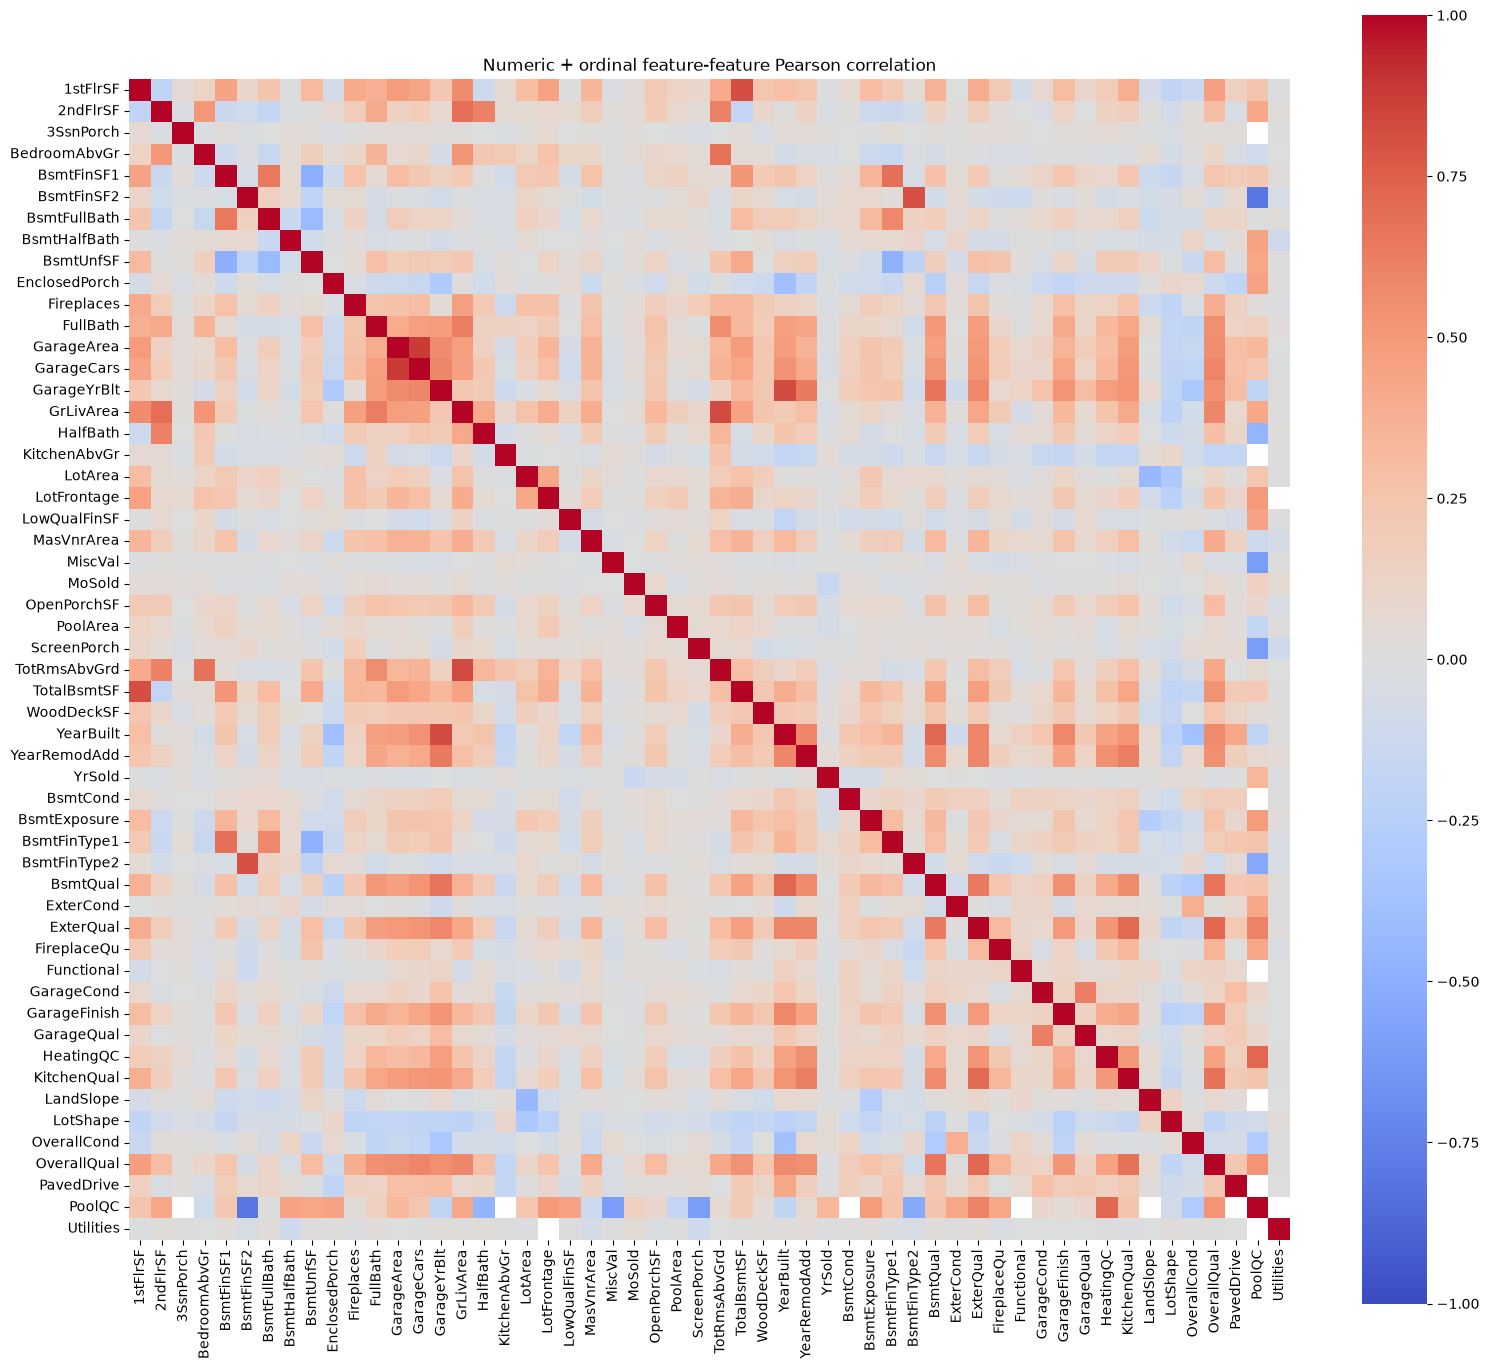

In [5]:
combined = pd.concat([df_train[NUMERIC_COLS], ordinal_encoded], axis=1)
corr = combined.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Numeric + ordinal feature-feature Pearson correlation")
plt.tight_layout()
plt.show()


In [6]:
# every pair at |r| >= 0.6, most-correlated first — the heatmap is too
# dense at 54x54 to read off exact pairs by eye
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("r")
    .reset_index()
    .rename(columns={"level_0": "feat1", "level_1": "feat2"})
)
pairs["abs_r"] = pairs["r"].abs()
high_corr_pairs = pairs[pairs["abs_r"] >= 0.6].sort_values("abs_r", ascending=False).drop(columns="abs_r")
high_corr_pairs


,feat1,feat2,r
661,GarageArea,GarageCars,0.882475
786,GarageYrBlt,YearBuilt,0.825667
837,GrLivArea,TotRmsAbvGrd,0.825489
28,1stFlrSF,TotalBsmtSF,0.819530
306,BsmtFinSF2,BsmtFinType2,0.805212
322,BsmtFinSF2,PoolQC,-0.799563
2156,ExterQual,OverallQual,0.726278
1657,YearBuilt,BsmtQual,0.725563
2482,HeatingQC,PoolQC,0.720277
2152,ExterQual,KitchenQual,0.716122


**Reading the pairs table:**

- `GarageArea`/`GarageCars` (0.88), `GrLivArea`/`TotRmsAbvGrd` (0.83),
  `1stFlrSF`/`TotalBsmtSF` (0.82) — different ways of measuring the same
  underlying "how big is this house" fact. Expected, and the main
  motivation for this notebook.
- `GarageYrBlt`/`YearBuilt` (0.83) — most garages are built with the house;
  a `GarageYrBlt`-`YearBuilt` delta would likely carry more information
  than either raw year on its own (a preprocessing/feature-engineering
  question, not resolved here).
- `ExterQual`/`OverallQual` (0.73), `BsmtQual`/`OverallQual` (0.66),
  `KitchenQual`/`ExterQual` (0.72) — the quality ordinals cluster together,
  consistent with `OverallQual` being a human-assigned summary of the
  same thing the component-quality columns measure individually.
- `BsmtFinSF2`/`PoolQC` (-0.80) and `BsmtFinSF2`/`BsmtFinType2` (0.81) are
  suspicious rather than meaningful: `BsmtFinSF2` is 88% zero and `PoolQC`
  is 99.5% missing (7 non-null) — a correlation computed on that few
  non-degenerate, mostly-non-overlapping rows is unstable, not a real
  relationship. Flagged as a measurement artifact, not a modeling risk.

### Structural identities

Two of the pairs above aren't just correlated — they're exact sums by
construction. Worth confirming directly, because a linear model that
includes both a total and its parts has a mathematically redundant
(singular) design matrix, which is a stronger problem than ordinary
correlation.

In [7]:
total_bsmt_check = (df_train["TotalBsmtSF"] == df_train["BsmtFinSF1"] + df_train["BsmtFinSF2"] + df_train["BsmtUnfSF"]).mean()
gr_liv_check = (df_train["GrLivArea"] == df_train["1stFlrSF"] + df_train["2ndFlrSF"] + df_train["LowQualFinSF"]).mean()
print(f"TotalBsmtSF == BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF: {total_bsmt_check:.0%} of rows")
print(f"GrLivArea == 1stFlrSF + 2ndFlrSF + LowQualFinSF:    {gr_liv_check:.0%} of rows")


TotalBsmtSF == BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF: 100% of rows
GrLivArea == 1stFlrSF + 2ndFlrSF + LowQualFinSF:    100% of rows


Both hold for 100% of rows — not a coincidence of this sample, a
definitional identity in how the dataset was built. `TotalBsmtSF` and
`GrLivArea` are aggregates of their own listed components. A model
shouldn't be given a total and every part that sums to it; pick one
representation per group at preprocessing time (the total alone loses
the finished/unfinished split, the parts alone lose the convenient
single-number summary — a genuine tradeoff, not resolved here).

## Variance Inflation Factor (VIF)

Correlation only looks at pairs. `OverallQual` could be weakly correlated
with every individual quality column while still being almost perfectly
*predictable* from all of them combined — VIF catches that. For feature
$j$, regress it on every other feature and compute
$\text{VIF}_j = \dfrac{1}{1 - R^2_j}$: how much $j$'s variance is
inflated by its linear relationship with the rest. Rule of thumb: >5
worth a look, >10 a real problem.

Unlike `corr()`, a linear regression needs complete rows. `PoolQC`
(99.5% missing) and `FireplaceQu` (47% missing) are excluded outright —
too sparse for this to be about anything but them. The remaining
structural NaNs (basement/garage columns, `LotFrontage`, `MasVnrArea`)
are handled with `.dropna()`, not filled — consistent with
[2_missingness.ipynb](2_missingness.ipynb)'s study-only convention;
row-exclusion for a throwaway diagnostic, not a value fabricated into
the data.

In [8]:
VIF_COLS = [c for c in combined.columns if c not in ("PoolQC", "FireplaceQu")]
complete = combined[VIF_COLS].dropna()
print(f"complete-case rows for VIF: {len(complete)} / {len(combined)}")

def compute_vif(frame):
    X_all = StandardScaler().fit_transform(frame.values)
    vif = {}
    for i, col in enumerate(frame.columns):
        y = X_all[:, i]
        X = np.delete(X_all, i, axis=1)
        r2 = LinearRegression().fit(X, y).score(X, y)
        vif[col] = np.inf if r2 >= 1 - 1e-12 else 1 / (1 - r2)
    return pd.Series(vif).sort_values(ascending=False)

vif_raw = compute_vif(complete)
vif_raw.head(10)


complete-case rows for VIF: 1095 / 1460


1stFlrSF             inf
2ndFlrSF             inf
BsmtFinSF2           inf
BsmtFinSF1           inf
BsmtUnfSF            inf
GrLivArea            inf
TotalBsmtSF          inf
LowQualFinSF         inf
Utilities            inf
YearBuilt       7.729597
dtype: float64

9 columns come back infinite — not a bug. `TotalBsmtSF`/`GrLivArea` and
their components are perfectly predictable from each other (the identity
confirmed above), and `Utilities` has zero variance in this particular
complete-case subset (every one of the 1095 remaining rows is `AllPub` —
the same near-zero-variance finding
[4_bivariate.ipynb](4_bivariate.ipynb) already flagged as an undecidable
drop candidate, showing up again here from a different angle). Re-running
with the two totals and `Utilities` dropped isolates the VIF signal that's
actually about *other* features, not these known issues.

In [9]:
VIF_COLS_CLEAN = [c for c in VIF_COLS if c not in ("TotalBsmtSF", "GrLivArea", "Utilities")]
complete_clean = combined[VIF_COLS_CLEAN].dropna()
vif_clean = compute_vif(complete_clean)
vif_clean.head(15)


BsmtFinSF1      11.056333
1stFlrSF         9.962408
BsmtUnfSF        9.888062
YearBuilt        7.729597
2ndFlrSF         5.867485
GarageYrBlt      5.128318
TotRmsAbvGrd     4.732951
GarageArea       4.642366
GarageCars       4.479895
BsmtFinSF2       4.070167
OverallQual      4.047450
ExterQual        3.416114
BsmtQual         3.362047
YearRemodAdd     3.276849
FullBath         3.240385
dtype: float64

In [10]:
print("n VIF > 10:", (vif_clean > 10).sum())
print("n VIF > 5: ", (vif_clean > 5).sum())


n VIF > 10: 1
n VIF > 5:  6


**Decision:** once the identities and `Utilities` are set aside, only
`BsmtFinSF1` clears 10 (11.1), and 5 more sit in the 4-6 "worth watching"
range (`1stFlrSF`, `BsmtUnfSF`, `YearBuilt`, `2ndFlrSF`, `GarageYrBlt`) —
all explainable by the same basement/floor-area and garage/house-year
groupings already called out above. No broad multicollinearity problem
across the 51 remaining features; the real, actionable finding is the two
structural identities, not a long VIF tail.

## Nominal feature association (Cramér's V)

Correlation and VIF assume numeric or ordered inputs — meaningless for
nominal categories. Cramér's V is the categorical analog: built from a
chi-square test of independence between two columns' crosstab, normalized
by sample size and table shape so it lands in [0, 1] regardless of how
many categories either column has. 0 means independent, 1 means one
column is fully determined by the other.

Lower stakes here than the numeric section — nominal columns get one-hot
encoded, and a model with regularization or tree splits handles redundant
dummy columns more gracefully than raw multicollinearity in a plain linear
fit. Still worth knowing which nominal columns are duplicating information.

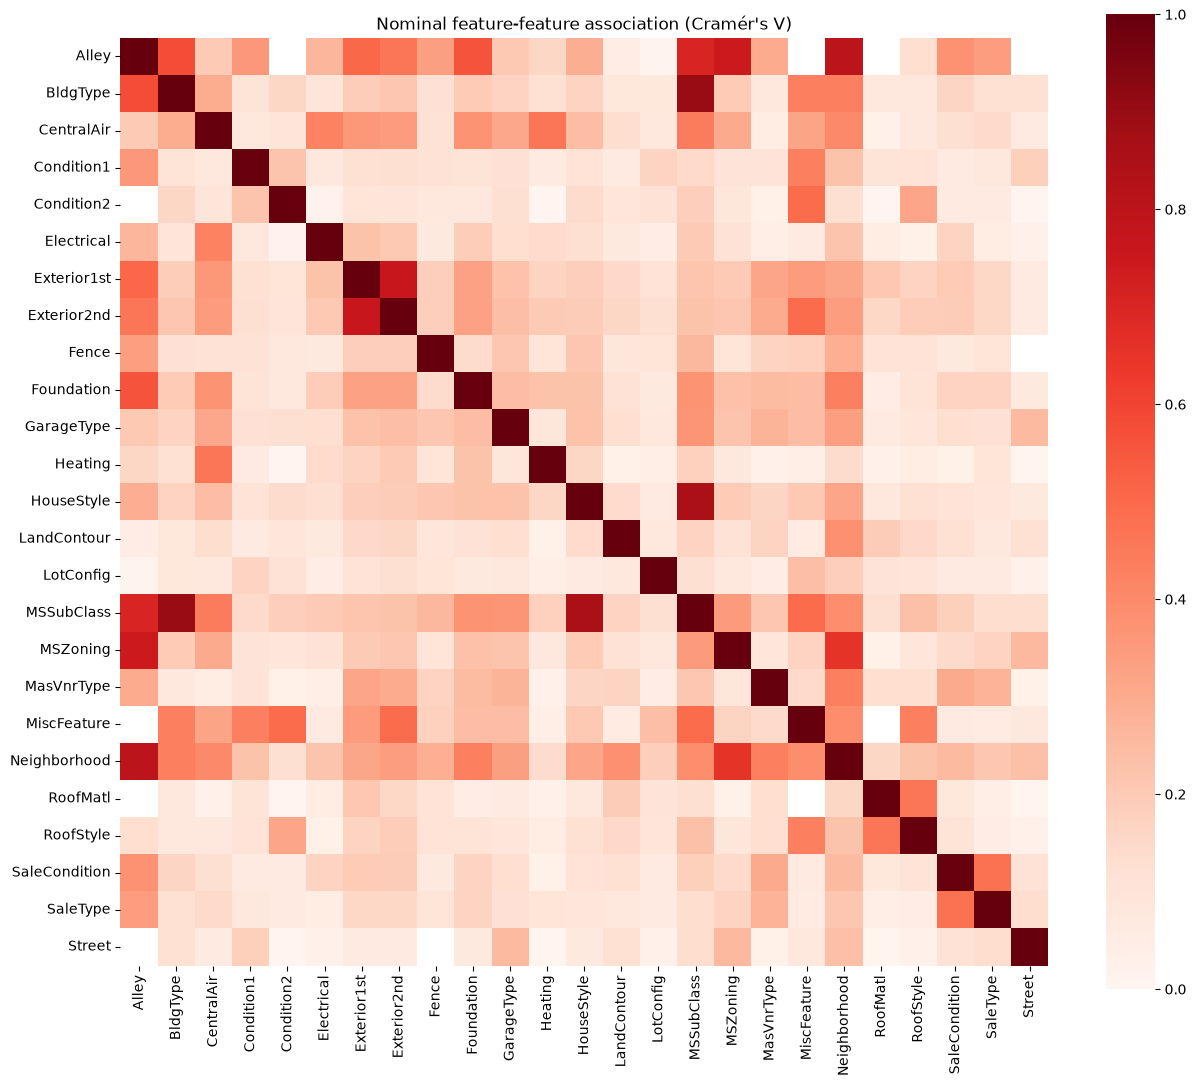

In [11]:
def cramers_v(a, b):
    ct = pd.crosstab(a, b)  # drops NaN pairs by default
    n = ct.values.sum()
    row_sums = ct.values.sum(axis=1, keepdims=True)
    col_sums = ct.values.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / n
    chi2 = np.nansum(np.where(expected > 0, (ct.values - expected) ** 2 / expected, 0))
    r, k = ct.shape
    denom = min(r - 1, k - 1)
    return np.nan if denom == 0 else np.sqrt((chi2 / n) / denom), n

nominal_assoc = pd.DataFrame(index=NOMINAL_COLS, columns=NOMINAL_COLS, dtype=float)
nominal_assoc_n = pd.DataFrame(index=NOMINAL_COLS, columns=NOMINAL_COLS, dtype=int)
for c1 in NOMINAL_COLS:
    for c2 in NOMINAL_COLS:
        if c1 == c2:
            nominal_assoc.loc[c1, c2], nominal_assoc_n.loc[c1, c2] = 1.0, df_train[c1].notna().sum()
        else:
            v, n = cramers_v(df_train[c1], df_train[c2])
            nominal_assoc.loc[c1, c2], nominal_assoc_n.loc[c1, c2] = v, n

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(nominal_assoc.astype(float), cmap="Reds", vmin=0, vmax=1, ax=ax, square=True)
ax.set_title("Nominal feature-feature association (Cramér\'s V)")
plt.tight_layout()
plt.show()


In [12]:
# top pairs, with the crosstab n each was computed on — Cramer's V on a
# thin crosstab is as unreliable as any other statistic on a thin sample
nom_pairs = (
    nominal_assoc.where(np.triu(np.ones(nominal_assoc.shape), k=1).astype(bool))
    .stack()
    .rename("cramers_v")
    .reset_index()
    .rename(columns={"level_0": "feat1", "level_1": "feat2"})
)
nom_pairs["n"] = nom_pairs.apply(lambda r: nominal_assoc_n.loc[r["feat1"], r["feat2"]], axis=1)
nom_pairs.sort_values("cramers_v", ascending=False).head(12)


,feat1,feat2,cramers_v,n
40,BldgType,MSSubClass,0.895535,1460.0
315,HouseStyle,MSSubClass,0.851591,1460.0
19,Alley,Neighborhood,0.801963,91.0
157,Exterior1st,Exterior2nd,0.762010,1460.0
16,Alley,MSZoning,0.743918,91.0
15,Alley,MSSubClass,0.704263,91.0
419,MSZoning,Neighborhood,0.652480,1460.0
1,Alley,BldgType,0.578663,91.0
9,Alley,Foundation,0.561003,91.0
6,Alley,Exterior1st,0.506666,91.0


**Reading the pairs table:**

- `BldgType`/`MSSubClass` (0.90) and `HouseStyle`/`MSSubClass` (0.85) —
  expected. `MSSubClass` is a dwelling-type code (per
  [0_load_and_orient.ipynb](0_load_and_orient.ipynb)'s gotcha note) that's
  substantially a combination of building type and house style by
  definition.
- `Exterior1st`/`Exterior2nd` (0.76, n=1460) — the two exterior-material
  columns agree on most houses (single-material homes have the same value
  in both), a real and expected redundancy.
- `Alley`/`Neighborhood` (0.80) and `Alley`/`MSZoning` (0.74) look like the
  strongest associations after the `MSSubClass` group, but `Alley` is 94%
  missing (`crosstab` drops NaNs, so these are computed on n=91) — too thin
  to trust at face value, the same reliability caveat
  [4_bivariate.ipynb](4_bivariate.ipynb) applied to sparse subsets
  throughout.

**Decision:** the one actionable redundancy is `MSSubClass` vs.
`BldgType`/`HouseStyle` — three columns carrying overlapping information
about dwelling type and form. `Exterior1st`/`Exterior2nd` is expected
redundancy inherent to the two-material design, not a data problem.
Nothing here reaches a level that demands dropping a column outright;
noted for preprocessing to watch, not acted on.

## Summary

| Section | What was checked | Key finding |
|---|---|---|
| Numeric + ordinal correlation | 54 columns, all pairs | 28 pairs at \|r\| ≥ 0.6; mostly expected size/quality clusters, plus one artifact pair (`BsmtFinSF2`/`PoolQC`) from near-empty overlap |
| Structural identities | `TotalBsmtSF`, `GrLivArea` | Both are exact sums of their own listed component columns (100% of rows) — not correlation, a data-generating identity |
| VIF | 51 columns (excl. `PoolQC`/`FireplaceQu`, and the identities/`Utilities` after the first pass) | Only `BsmtFinSF1` clears 10; 5 more in the 4-6 range; no broad multicollinearity problem once the identities are set aside |
| Nominal (Cramér's V) | 25 columns, all pairs | `MSSubClass`/`BldgType`/`HouseStyle` cluster (0.85-0.90) and `Exterior1st`/`Exterior2nd` (0.76) are the only associations both strong and well-supported by sample size |

**Candidates carried forward to preprocessing:**

- **Pick one representation per structural-identity group** — `TotalBsmtSF`
  vs. `BsmtFinSF1`+`BsmtFinSF2`+`BsmtUnfSF`, and `GrLivArea` vs.
  `1stFlrSF`+`2ndFlrSF`+`LowQualFinSF`. Including both sides in a linear
  model creates a singular design matrix; even for tree models it's
  redundant signal for no benefit.
- **`GarageYrBlt`/`YearBuilt`** (r=0.83): consider engineering a delta
  (garage age relative to house age) instead of keeping both raw years.
- **`GarageArea`/`GarageCars`** (r=0.88): near-duplicate size measures;
  keeping both is low-risk (VIF stayed under 5 for both) but worth a note.
- **Quality-ordinal cluster** (`OverallQual`, `ExterQual`, `BsmtQual`,
  `KitchenQual`, mutual r in the 0.6-0.73 range): expected structure, not
  flagged as a problem — VIF confirmed no single one is a near-linear
  combination of the rest.
- **`BsmtFinSF1`** (VIF=11.1): mildly redundant with the rest of the
  basement/floor-area group; not severe enough alone to justify dropping.
- **Nominal**: `MSSubClass` substantially overlaps `BldgType`/`HouseStyle`
  — worth checking whether a model benefits from all three or just
  `MSSubClass` alone.
- **Boundary held:** every finding above is a flag — no column was
  dropped, combined, or transformed in this notebook.